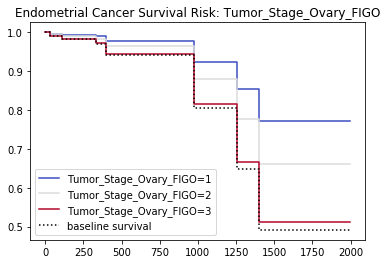

In [1]:
import cptac
import pandas as pd
import numpy as np
import seaborn as sns
from lifelines import CoxPHFitter

ov = cptac.Ovarian()
omics_genes = pd.Series(['RAC2', 'PODXL'])
clinical_and_protein = ov.join_metadata_to_omics(metadata_df_name="clinical", omics_df_name="proteomics", 
                                                 omics_genes=omics_genes, quiet=True)
clinical_and_protein = ov.reduce_multiindex(clinical_and_protein, levels_to_drop="Database_ID")
clin_prot_follow = pd.merge(clinical_and_protein, ov.get_followup(), on="Patient_ID")
columns_to_focus_on = ['Vital_Status', 'Days_Between_Collection_And_Last_Contact', 
                       'Days_Between_Collection_And_Death', 'Tumor_Stage_Ovary_FIGO']
omics_genes = omics_genes +  '_proteomics'
columns_to_focus_on.extend(omics_genes.tolist())
focus_group = clin_prot_follow[columns_to_focus_on].copy().drop_duplicates()
focus_group['Vital_Status'] = focus_group['Vital_Status'].replace(
    {'Living': False, 'Deceased': True}).astype('bool')
cols = ['Days_Between_Collection_And_Last_Contact', 'Days_Between_Collection_And_Death']
focus_group = focus_group.assign(Days_Until_Last_Contact_Or_Death=focus_group[cols].sum(1)).drop(cols, 1)
for col in omics_genes:
    lower_25_filter = focus_group[col] <= focus_group[col].quantile(.25)
    upper_25_filter = focus_group[col] >= focus_group[col].quantile(.75)
    focus_group[col] = np.where(lower_25_filter, "Lower_25%", focus_group[col])
    focus_group[col] = np.where(upper_25_filter, "Upper_25%", focus_group[col])
    focus_group[col] = np.where(~lower_25_filter & ~upper_25_filter, "Middle_50%", focus_group[col])
for gene in omics_genes:
    focus_group[gene] = focus_group[gene].map({"Lower_25%" : 1, "Middle_50%" : 2, "Upper_25%" : 3})
focus_group['Tumor_Stage_Ovary_FIGO'] = focus_group['Tumor_Stage_Ovary_FIGO'].map(
    {"IIIC" : 3, "IV" : 4, "IIIB" : 3, "Not Reported/ Unknown" : np.nan, 
     "IIIA" : 3, "III" : 3, "IC" : 1, "IIB" : 2})
cph = CoxPHFitter()
cph.fit(focus_group.dropna(axis=0, how='any'), duration_col="Days_Until_Last_Contact_Or_Death", 
        event_col="Vital_Status")
axes = cph.plot_covariate_groups('Tumor_Stage_Ovary_FIGO', [1,2,3], cmap='coolwarm', 
                                 title="Endometrial Cancer Survival Risk: Tumor_Stage_Ovary_FIGO")